# Quinta Playa (Isabela, Galápagos): daily SLA vs. ENSO

Pipeline: **daily SLA (CSV) → linear detrend (daily) → monthly means → remove seasonal cycle → compare with ENSO indices → El Niño / Neutral / La Niña composites (MEI ±0.5σ, Vos et al. 2023)**.

Everything after the monthly aggregation step is deliberately *monthly*, because the ENSO indices are monthly
and the Wilcoxon tests need roughly independent samples (30 daily values in one month are not 30 independent samples).

## 1. Setup and paths

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from scipy.stats import pearsonr, wilcoxon


def find_data_dir(name="data"):
    """Walk up from the current working directory until a folder called `data` is found.
    Works whether Jupyter's cwd is the repo root or the notebooks/ folder."""
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / name).is_dir():
            return base / name
    raise FileNotFoundError(f"Could not find a '{name}' folder above {Path.cwd()}")


DATA_DIR = find_data_dir()

# Expected location: <repo>/data/sla/sla_quinta_daily.csv
SLA_CSV = DATA_DIR / "sla" / "sla_quinta_daily.csv"
if not SLA_CSV.exists():  # fall back to searching anywhere under data/
    matches = sorted(DATA_DIR.rglob("sla_quinta_daily.csv"))
    if not matches:
        raise FileNotFoundError(f"sla_quinta_daily.csv not found under {DATA_DIR}")
    SLA_CSV = matches[0]

print("Data dir :", DATA_DIR)
print("SLA CSV  :", SLA_CSV)

Data dir : c:\TUD\MDP\quintaplaya\data
SLA CSV  : c:\TUD\MDP\quintaplaya\data\sla\sla_quinta_daily.csv


## 2. Load daily SLA and sanity-check it

Period          : 1993-01-01 → 2026-09-21
Rows            : 12317
Duplicate dates : 0
Missing days    : 0
NaN values      : 0
SLA range       : -0.108 to 0.420 m


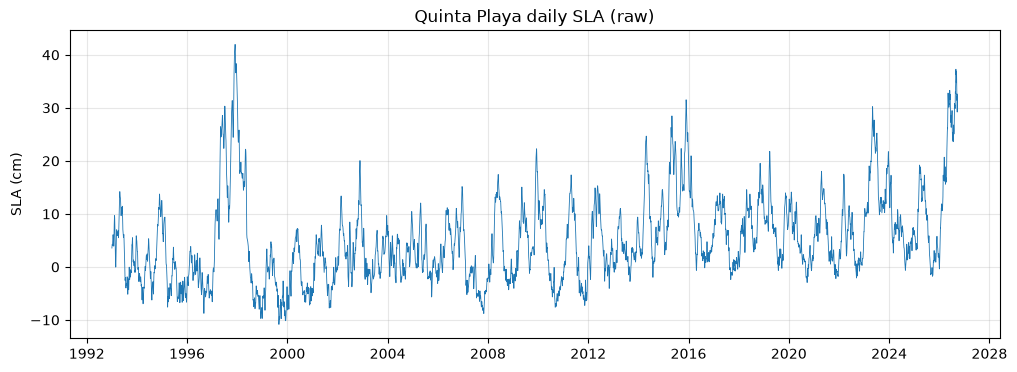

In [2]:
daily = pd.read_csv(SLA_CSV, parse_dates=["time"], index_col="time").sort_index()
sla_daily = daily["sla"].astype(float)          # metres; `adt` is just sla + a constant, so unused here

full_range = pd.date_range(sla_daily.index.min(), sla_daily.index.max(), freq="D")
print(f"Period          : {sla_daily.index.min():%Y-%m-%d} → {sla_daily.index.max():%Y-%m-%d}")
print(f"Rows            : {len(sla_daily)}")
print(f"Duplicate dates : {sla_daily.index.duplicated().sum()}")
print(f"Missing days    : {len(full_range.difference(sla_daily.index))}")
print(f"NaN values      : {sla_daily.isna().sum()}")
print(f"SLA range       : {sla_daily.min():.3f} to {sla_daily.max():.3f} m")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sla_daily.index, sla_daily * 100, lw=0.6)
ax.set_ylabel("SLA (cm)")
ax.set_title("Quinta Playa daily SLA (raw)")
ax.grid(alpha=0.3)
plt.show()

## 3. Remove the long-term linear trend

Time is expressed in **years** (days / 365.25), so the slope is directly m/yr.
(The monthly version used `slope * 12` because the x-axis was a month counter; that would be wrong for daily data.)

Linear trend: 2.87 mm/year


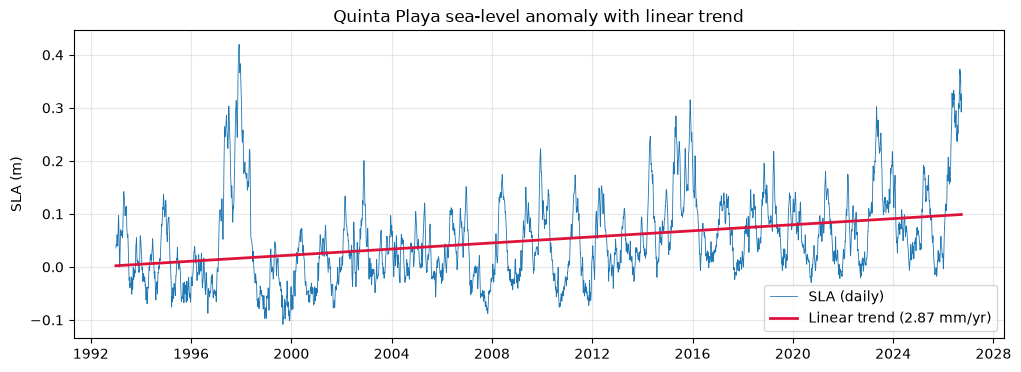

In [3]:
t_years = ((sla_daily.index - sla_daily.index[0]) / pd.Timedelta(days=365.25)).to_numpy()
ok = sla_daily.notna().to_numpy()

slope, intercept = np.polyfit(t_years[ok], sla_daily.to_numpy()[ok], 1)   # slope in m/yr
trend = pd.Series(intercept + slope * t_years, index=sla_daily.index)
sla_detrended = sla_daily - trend

print(f"Linear trend: {slope * 1000:.2f} mm/year")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sla_daily.index, sla_daily, lw=0.6, label="SLA (daily)")
ax.plot(trend.index, trend, color="crimson", lw=2, label=f"Linear trend ({slope * 1000:.2f} mm/yr)")
ax.set_ylabel("SLA (m)")
ax.set_title("Quinta Playa sea-level anomaly with linear trend")
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 4. Aggregate to monthly means and remove the seasonal cycle

Months with less than `MIN_COVERAGE` of their days observed (e.g. a partial current month) are set to NaN so an
incomplete month is not compared against a full-month climatology.

In [4]:
MIN_COVERAGE = 0.8

resampler = sla_detrended.resample("MS")               # "MS" = month start, same convention as the ENSO indices
sla_monthly = resampler.mean()
coverage = resampler.count() / sla_monthly.index.days_in_month
sla_monthly[coverage < MIN_COVERAGE] = np.nan

dropped = sla_monthly.index[coverage < MIN_COVERAGE]
if len(dropped):
    print("Dropped incomplete months:", [d.strftime("%Y-%m") for d in dropped])

# Seasonal cycle = mean of each calendar month; anomalies in cm
monthly_clim = sla_monthly.groupby(sla_monthly.index.month).transform("mean")
sla_anom = ((sla_monthly - monthly_clim) * 100).rename("SLA_cm")

TARGET_TIME = sla_anom.index            # common monthly axis for everything below
print(f"{sla_anom.notna().sum()} valid months, {TARGET_TIME[0]:%Y-%m} → {TARGET_TIME[-1]:%Y-%m}")

Dropped incomplete months: ['2026-09']
404 valid months, 1993-01 → 2026-09


## 5. Load the ENSO indices

* **Niño 1+2** → lag correlation and time-series plot (sections 6-7): the box containing the Galápagos.
* **MEI v2** → El Niño / La Niña event classification (section 8).

The loader picks the 1-D data variable with a `time` dimension (skipping `*_bnds` variables), masks fill values
such as -99.99 / -999 that were not flagged in the file, and snaps timestamps to month start.
The printout shows each index's time coverage.

In [17]:
ENSO_FILES = {
    "MEI v2":   DATA_DIR / "enso" / "meiv2.nc",
    "Niño 1+2": DATA_DIR / "enso" / "nino12.long.anom.nc",
    "Niño 3.4": DATA_DIR / "enso" / "nino34.long.anom.nc",     # uncomment to add it back
}


def load_enso_index(path, label):
    if not Path(path).exists():
        found = "\n  ".join(str(p.relative_to(DATA_DIR)) for p in sorted(DATA_DIR.rglob("*.nc"))) or "(none)"
        raise FileNotFoundError(f"{label}: {path} not found. NetCDF files under {DATA_DIR}:\n  {found}")

    with xr.open_dataset(path) as ds:
        candidates = [
            v for v in ds.data_vars
            if "time" in ds[v].dims
            and "bnds" not in v.lower() and "bounds" not in v.lower()
            and ds[v].squeeze(drop=True).ndim == 1            # a plain time series (singleton lat/lon are squeezed away)
        ]
        if not candidates:
            raise ValueError(f"{label}: no 1-D time series in {path.name}; variables: {list(ds.data_vars)}")
        var = candidates[0]
        series = ds[var].squeeze(drop=True).to_series()

    if not isinstance(series.index, pd.DatetimeIndex):        # non-standard calendar (cftime) -> plain datetimes
        series.index = pd.to_datetime([t.strftime("%Y-%m-%d") for t in series.index])
    series = series[~series.index.duplicated()].sort_index()
    series = series.where(series.abs() < 90)                  # unmasked fill values (-99.99, -999, ...)
    series = series.resample("MS").mean().rename(label)       # snap mid-month / month-end stamps to month start

    valid = series.dropna()
    print(f"{label:<9} ← '{var}' in {Path(path).name}: {valid.index[0]:%Y-%m} → {valid.index[-1]:%Y-%m}, {len(valid)} valid months")
    return series


indices = pd.concat([load_enso_index(p, name) for name, p in ENSO_FILES.items()], axis=1)
indices = indices.reindex(TARGET_TIME)                        # same monthly axis as SLA

sla_last = sla_anom.dropna().index[-1]
for name in indices.columns:
    last = indices[name].dropna().index[-1]
    if last < sla_last:
        print(f"Note: {name} ends {last:%Y-%m} but SLA runs to {sla_last:%Y-%m}; later months drop out of the analysis.")
print()
print(indices.describe().round(2))

MEI v2    ← 'value' in meiv2.nc: 1979-01 → 2026-08, 572 valid months
Niño 1+2  ← 'value' in nino12.long.anom.nc: 1870-01 → 2026-07, 1879 valid months
Niño 3.4  ← 'value' in nino34.long.anom.nc: 1870-01 → 2026-07, 1879 valid months
Note: Niño 1+2 ends 2026-07 but SLA runs to 2026-08; later months drop out of the analysis.
Note: Niño 3.4 ends 2026-07 but SLA runs to 2026-08; later months drop out of the analysis.

       MEI v2  Niño 1+2  Niño 3.4
count  404.00    403.00    403.00
mean    -0.20     -0.00      0.01
std      0.97      1.04      0.85
min     -2.42     -1.95     -1.79
25%     -0.91     -0.67     -0.57
50%     -0.31     -0.20     -0.08
75%      0.37      0.36      0.48
max      2.61      4.27      2.57


C:\Users\nagye\AppData\Local\Temp\ipykernel_26748\2020805422.py:36: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  indices = pd.concat([load_enso_index(p, name) for name, p in ENSO_FILES.items()], axis=1)


## 6. Lag correlation: SLA anomaly vs Niño 1+2

Uses the **detrended, deseasonalised monthly SLA anomaly** (the interannual signal) rather than raw SLA,
so the trend and the seasonal cycle do not contaminate the correlation.
Positive lag = ENSO index leads SLA.

Positive lag means the ENSO index leads SLA.
Zero-lag Pearson correlations:
MEI v2      0.684
Niño 1+2    0.826
Niño 3.4    0.743
Name: 0, dtype: float64

Best lag within ±6 months:
MEI v2: lag -1 months, r = 0.724
Niño 1+2: lag -1 months, r = 0.842
Niño 3.4: lag -1 months, r = 0.776


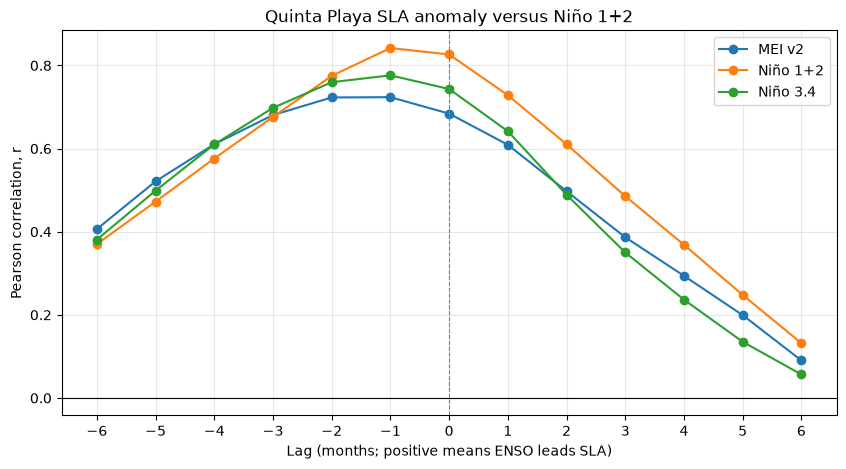

In [18]:
aligned = pd.concat([sla_anom, indices], axis=1)
lags = range(-6, 7)
CORR_INDICES = ["MEI v2", "Niño 1+2", "Niño 3.4"]   # all three back in the comparison
correlations = {name: [] for name in CORR_INDICES}

for name in CORR_INDICES:
    for lag in lags:
        pair = pd.concat([aligned["SLA_cm"], aligned[name].shift(lag)], axis=1).dropna()
        r, _ = pearsonr(pair.iloc[:, 0], pair.iloc[:, 1])
        correlations[name].append(r)

correlation_table = pd.DataFrame(correlations, index=list(lags))
correlation_table.index.name = "lag_months"

print("Positive lag means the ENSO index leads SLA.")
print("Zero-lag Pearson correlations:")
print(correlation_table.loc[0].round(3))
print("\nBest lag within ±6 months:")
for name in correlation_table.columns:
    best = correlation_table[name].abs().idxmax()
    print(f"{name}: lag {best:+d} months, r = {correlation_table.loc[best, name]:.3f}")

fig, ax = plt.subplots(figsize=(10, 5))
for name in correlation_table.columns:
    ax.plot(correlation_table.index, correlation_table[name], marker="o", lw=1.5, label=name)
ax.axhline(0, color="black", lw=0.8)
ax.axvline(0, color="gray", ls="--", lw=0.8)
ax.set_xlabel("Lag (months; positive means ENSO leads SLA)")
ax.set_ylabel("Pearson correlation, r")
ax.set_title("Quinta Playa SLA anomaly versus Niño 1+2")
ax.set_xticks(list(lags))
ax.grid(alpha=0.3)
ax.legend()
plt.show()

## 7. SLA anomaly and Niño 1+2 through time

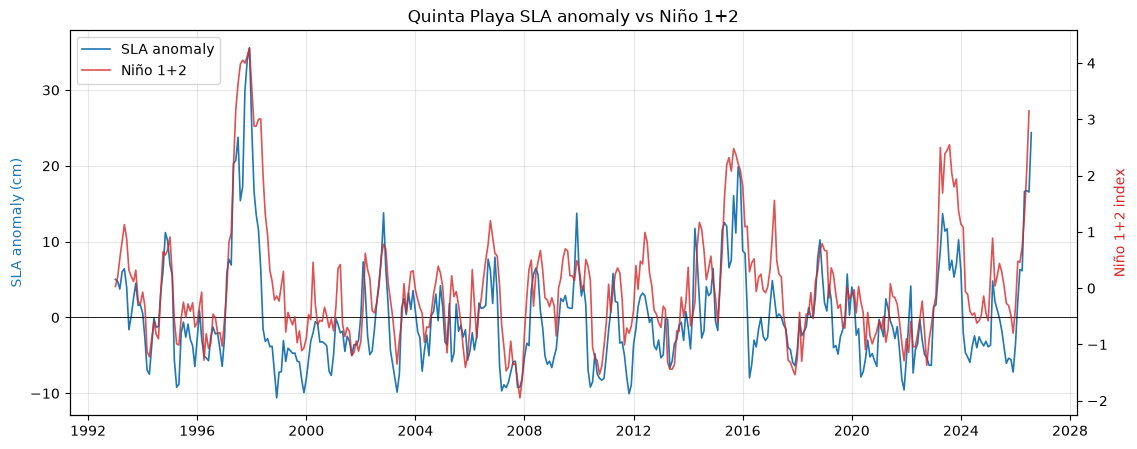

In [7]:
fig, ax1 = plt.subplots(figsize=(13, 5))
(h1,) = ax1.plot(sla_anom.index, sla_anom, color="tab:blue", lw=1.2, label="SLA anomaly")
ax1.set_ylabel("SLA anomaly (cm)", color="tab:blue")
ax1.axhline(0, color="black", lw=0.6)

ax2 = ax1.twinx()
(h2,) = ax2.plot(indices.index, indices["Niño 1+2"], color="tab:red", lw=1.2, alpha=0.8, label="Niño 1+2")
ax2.set_ylabel("Niño 1+2 index", color="tab:red")

ax1.legend(handles=[h1, h2], loc="upper left")
ax1.set_title("Quinta Playa SLA anomaly vs Niño 1+2")
ax1.grid(alpha=0.3)
plt.show()

## 8. Classify months as El Niño / Neutral / La Niña (MEI v2 ±0.5σ)

MEI σ = 0.966  →  threshold = ±0.483
Classified months:
phase
La Niña    176
Neutral    140
El Niño     88

Total months in analysis: 404  (1993-01 → 2026-08)


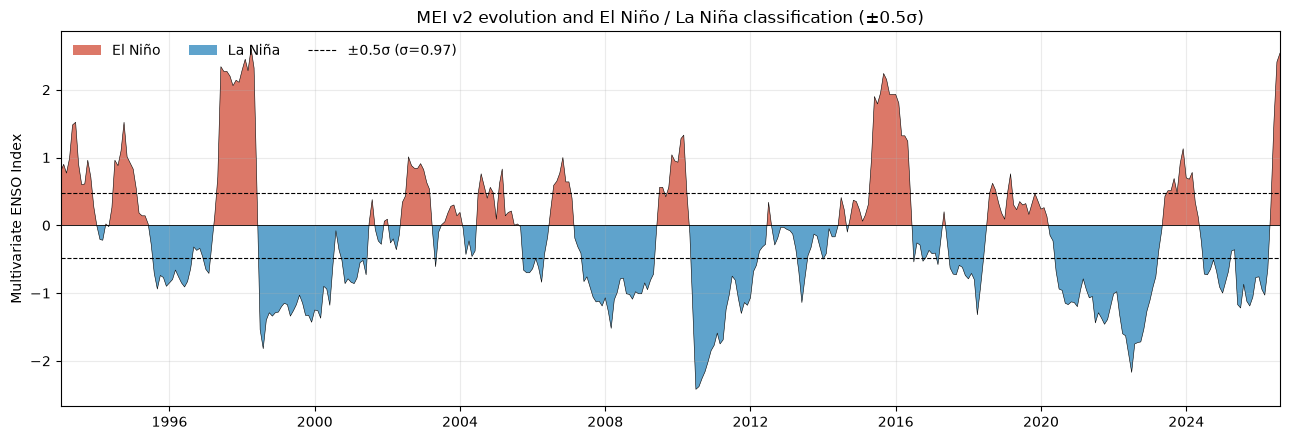

In [11]:
ENSO_THRESH = 0.5                                   # in standard deviations of MEI

mei = indices["MEI v2"].dropna()
sigma = mei.std()

enso_phase = pd.Series("Neutral", index=mei.index, name="phase")
enso_phase[mei >  ENSO_THRESH * sigma] = "El Niño"
enso_phase[mei < -ENSO_THRESH * sigma] = "La Niña"

df = pd.DataFrame({"SLA": sla_anom, "MEI": mei, "phase": enso_phase}).dropna()
df["season"] = df.index.month.map({12: "DJF", 1: "DJF", 2: "DJF", 3: "MAM", 4: "MAM", 5: "MAM",
                                   6: "JJA", 7: "JJA", 8: "JJA", 9: "SON", 10: "SON", 11: "SON"})

print(f"MEI σ = {sigma:.3f}  →  threshold = ±{ENSO_THRESH * sigma:.3f}")
print(f"Classified months:\n{df['phase'].value_counts().to_string()}")
print(f"\nTotal months in analysis: {len(df)}  ({df.index[0]:%Y-%m} → {df.index[-1]:%Y-%m})")

# ── MEI evolution / ENSO classification plot (cf. Vos et al. 2023, Fig. S3.4b) ──
fig, ax = plt.subplots(figsize=(13, 4.5))

ax.fill_between(mei.index, mei, 0, where=(mei > 0), color="#d6604d", alpha=0.85,
                lw=0, interpolate=True, label="El Niño")
ax.fill_between(mei.index, mei, 0, where=(mei < 0), color="#4393c3", alpha=0.85,
                lw=0, interpolate=True, label="La Niña")
ax.plot(mei.index, mei, color="black", lw=0.4)

ax.axhline(ENSO_THRESH * sigma, color="black", ls="--", lw=0.8,
           label=f"±{ENSO_THRESH}σ (σ={sigma:.2f})")
ax.axhline(-ENSO_THRESH * sigma, color="black", ls="--", lw=0.8)
ax.axhline(0, color="black", lw=0.6)

ax.set_ylabel("Multivariate ENSO Index")
ax.set_title("MEI v2 evolution and El Niño / La Niña classification (±0.5σ)")
ax.set_xlim(mei.index[0], mei.index[-1])
ax.legend(loc="upper left", ncol=3, frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

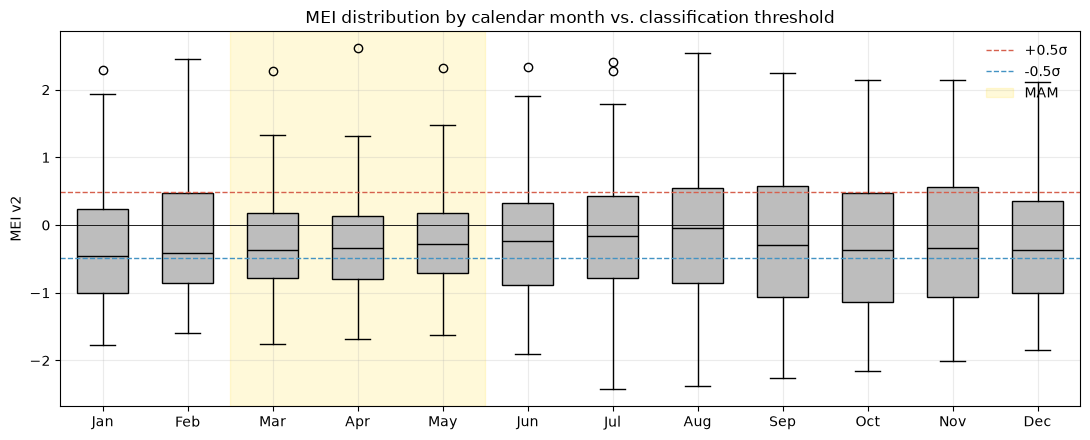

Fraction of months within ±0.2σ of the ±0.5σ threshold, by season:
time
DJF    0.198
JJA    0.255
MAM    0.255
SON    0.303
dtype: float64

Median MEI by season:
time
DJF   -0.42
JJA   -0.20
MAM   -0.32
SON   -0.32
Name: MEI v2, dtype: float32

El Niño / Neutral / La Niña month counts by season:
phase   El Niño  La Niña  Neutral
season                           
DJF          24       48       29
JJA          21       44       37
MAM          17       40       45
SON          26       44       29


In [16]:
# ── Diagnostic: does MAM cluster near the ±0.5σ threshold? ──────────────────
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
thresh = ENSO_THRESH * sigma

fig, ax = plt.subplots(figsize=(11, 4.5))
data = [mei[mei.index.month == m].to_numpy() for m in range(1, 13)]
bp = ax.boxplot(data, positions=range(1, 13), widths=0.6, patch_artist=True,
                medianprops=dict(color="black"))
for patch in bp["boxes"]:
    patch.set_facecolor("#bdbdbd")

ax.axhline( thresh, color="#d6604d", ls="--", lw=1, label=f"+{ENSO_THRESH}σ")
ax.axhline(-thresh, color="#4393c3", ls="--", lw=1, label=f"-{ENSO_THRESH}σ")
ax.axhline(0, color="black", lw=0.6)
ax.axvspan(2.5, 5.5, color="gold", alpha=0.15, label="MAM")   # Mar/Apr/May
ax.set_xticks(range(1, 13)); ax.set_xticklabels(month_names)
ax.set_ylabel("MEI v2")
ax.set_title("MEI distribution by calendar month vs. classification threshold")
ax.legend(loc="upper right", frameon=False)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# ── Numbers behind the boxplot: borderline fraction, typical MEI, and phase counts ──
thresh = ENSO_THRESH * sigma
season_of_mei = mei.index.month.map({12:"DJF",1:"DJF",2:"DJF", 3:"MAM",4:"MAM",5:"MAM",
                                      6:"JJA",7:"JJA",8:"JJA", 9:"SON",10:"SON",11:"SON"})

# 1) How often does each season sit right on the classification line?
near_threshold = (mei.abs() > thresh - 0.2 * sigma) & (mei.abs() < thresh + 0.2 * sigma)
frac_near = pd.Series(near_threshold.to_numpy(), index=season_of_mei).groupby(level=0).mean().round(3)
print("Fraction of months within ±0.2σ of the ±0.5σ threshold, by season:")
print(frac_near)

# 2) Is MAM's MEI just systematically weaker, independent of the threshold?
med_by_season = mei.groupby(season_of_mei).median().round(3)
print("\nMedian MEI by season:")
print(med_by_season)

# 3) Full phase breakdown per season (ties the two diagnostics back to your n=17 etc.)
counts = df.groupby(["season", "phase"]).size().unstack(fill_value=0)
print("\nEl Niño / Neutral / La Niña month counts by season:")
print(counts)
# Quantify: fraction of months in each season sitting within 0.2σ of the threshold
# (i.e. borderline classifications,

## 9. Wilcoxon signed-rank tests per phase and season

One-sample test against zero (the long-term mean after detrending/deseasonalising).
`alternative='greater'` for El Niño, `'less'` for La Niña.

In [9]:
PHASE_ALT = {"El Niño": "greater", "La Niña": "less"}
SEASONS = ["DJF", "MAM", "JJA", "SON"]
PHASES = ["El Niño", "Neutral", "La Niña"]


def wilcoxon_onesample(values, alternative):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) < 5:
        return np.nan
    try:
        return wilcoxon(values, alternative=alternative).pvalue
    except ValueError:                               # e.g. all values exactly zero
        return np.nan


panels = [("All seasons", df)] + [(s, df[df["season"] == s]) for s in SEASONS]

pvals = {}                                           # (panel, phase) -> p, reused by the boxplots
print(f"{'Panel':<12} {'Phase':<8} {'n':>4}  {'median':>9}  {'mean':>9}  {'p-value':>8}")
print("─" * 58)
for title, subset in panels:
    for ph, alt in PHASE_ALT.items():
        vals = subset.loc[subset["phase"] == ph, "SLA"].to_numpy()
        p = wilcoxon_onesample(vals, alt)
        pvals[(title, ph)] = p
        med = f"{np.median(vals):+.1f} cm" if len(vals) else "n/a"
        avg = f"{np.mean(vals):+.1f} cm" if len(vals) else "n/a"
        p_str = "n/a" if np.isnan(p) else f"{p:.4f}" + ("*" if p < 0.05 else "")
        print(f"{title:<12} {ph:<8} {len(vals):>4}  {med:>9}  {avg:>9}  {p_str:>8}")
    print()

Panel        Phase       n     median       mean   p-value
──────────────────────────────────────────────────────────
All seasons  El Niño    88    +6.2 cm    +7.5 cm   0.0000*
All seasons  La Niña   176    -3.7 cm    -3.4 cm   0.0000*

DJF          El Niño    24    +6.3 cm    +8.1 cm   0.0000*
DJF          La Niña    48    -4.6 cm    -4.2 cm   0.0000*

MAM          El Niño    17    +4.2 cm    +3.7 cm    0.0544
MAM          La Niña    40    -1.8 cm    -0.8 cm    0.1185

JJA          El Niño    21    +6.2 cm    +8.1 cm   0.0001*
JJA          La Niña    44    -3.2 cm    -2.9 cm   0.0000*

SON          El Niño    26    +6.6 cm    +8.9 cm   0.0000*
SON          La Niña    44    -5.3 cm    -5.2 cm   0.0000*



"Monthly SLA observations within a single ENSO event are serially correlated, meaning the effective sample size is closer to the number of independent events (~8–10 El Niño events over the record) than the number of months (n=88). The reported p-values should therefore be interpreted cautiously; the consistency of the signal across three of four seasons and its agreement with the lag correlation (r = 0.89) provide stronger evidence than any individual p-value."

## 10. Composite boxplots (cf. Vos et al. 2023, Fig. S3.5)

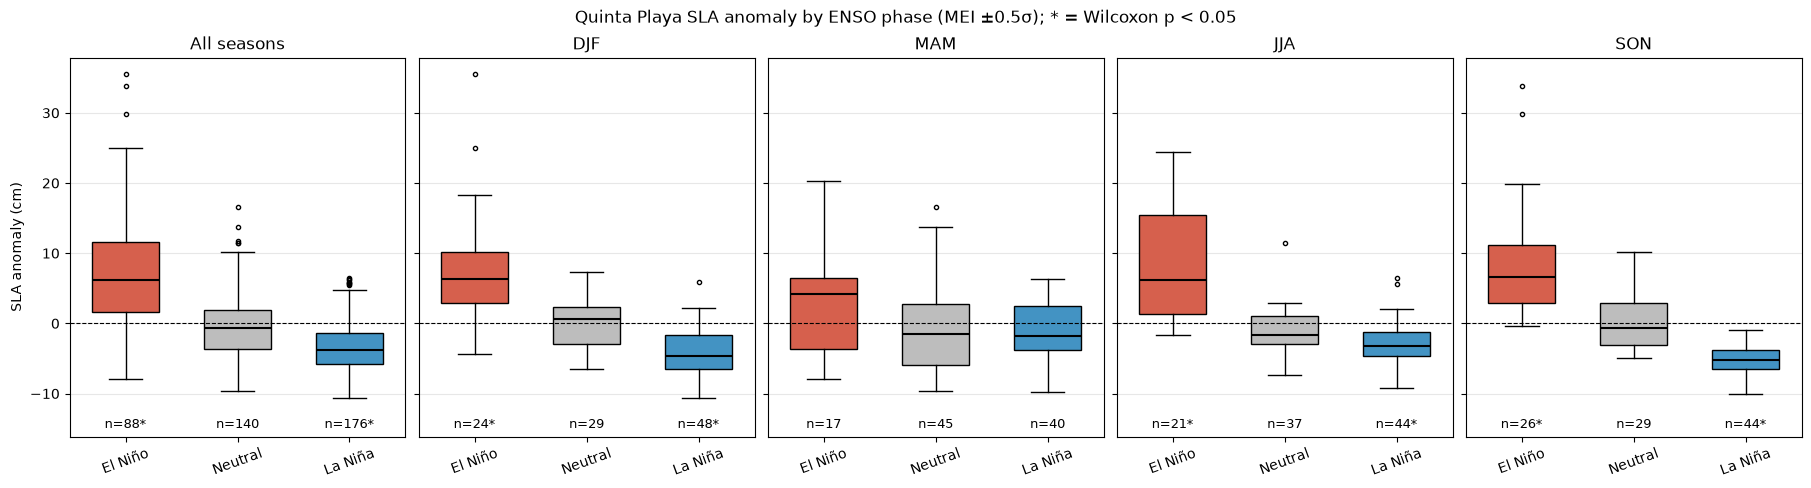

In [10]:
colors = {"El Niño": "#d6604d", "Neutral": "#bdbdbd", "La Niña": "#4393c3"}

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), sharey=True, constrained_layout=True)
for ax, (title, subset) in zip(axes, panels):
    data = [subset.loc[subset["phase"] == ph, "SLA"].to_numpy() for ph in PHASES]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6, showfliers=True,
                    medianprops=dict(color="black", lw=1.5), flierprops=dict(markersize=3))
    for patch, ph in zip(bp["boxes"], PHASES):
        patch.set_facecolor(colors[ph])
    ax.axhline(0, color="black", lw=0.8, ls="--")

    for i, (ph, vals) in enumerate(zip(PHASES, data), start=1):
        star = "*" if pvals.get((title, ph), np.nan) < 0.05 else ""       # NaN < 0.05 is False
        ax.text(i, 0.015, f"n={len(vals)}{star}", ha="center", va="bottom", fontsize=9,
                transform=ax.get_xaxis_transform())                       # y in axes fraction

    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(PHASES, rotation=20)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3)

lo, hi = df["SLA"].min(), df["SLA"].max()
axes[0].set_ylim(lo - 0.12 * (hi - lo), hi + 0.05 * (hi - lo))              # headroom for the n= labels
axes[0].set_ylabel("SLA anomaly (cm)")
fig.suptitle("Quinta Playa SLA anomaly by ENSO phase (MEI ±0.5σ); * = Wilcoxon p < 0.05", y=1.05)
plt.show()